# **Pré-processamento**


**Importação e Instalação** 


In [ ]:
!pip install seaborn --quiet
!pip install scikit-learn --quiet
!pip install statsmodels --quiet


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [146]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [147]:
df = pd.read_csv('dados_fundo_do_amanha_evcomx.csv', sep=';')

In [148]:
pd.set_option('display.max_columns', 22)
df.head(n=10)

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
1,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1652,1672,1543.0,1555.0
2,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1650,1670,1543.0,1555.0
3,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1655,1672,1543.0,1555.0
4,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
5,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1651,1672,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
7,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1681,1678,1543.0,1547.0
8,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1680,1678,1543.0,1547.0
9,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,55.0,1503.0,0.85,0.85,1677,1678,1543.0,1547.0


**Tamanho**

In [149]:
df.shape

(48658, 22)

**Tipo**

In [150]:
df.dtypes

corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
velocidadeobjetivada     float64
velocidadereal           float64
sugestaomodelolegado       int64
temperaturasaidafp         int64
temperaturaobjetivada    float64
temperaturamediareal     float64
dtype: object

**Percentual de dados faltantes por coluna**



In [151]:
faltantes = df.isnull().sum()
faltantes_percentual = (df.isnull().sum() / len(df['corrida'])) * 100
print(faltantes_percentual)

corrida                  0.000000
secao                    0.000000
acoatual                 0.000000
qualidade                0.000000
al_min                   0.000000
c_min                    0.000000
c_max                    0.000000
n_min                    0.000000
s_min                    0.000000
sequencia                0.000000
sequenciatotal           0.000000
panela                   0.000000
vidapanela               0.000000
tempociclo               0.000000
tempovacuototal          0.000000
temperaturaliquidus      0.000000
velocidadeobjetivada     0.000000
velocidadereal           0.000000
sugestaomodelolegado     0.000000
temperaturasaidafp       0.000000
temperaturaobjetivada    0.000000
temperaturamediareal     0.024662
dtype: float64


**Exclusão das linhas com valores nulos**

In [152]:
#Como a porcentagem de dados faltantes é irrelevante(menos de 5%) apenas descartamos os valores NAN e/ou nulos

df = df.dropna()

**Removendo colunas duplicadas**

In [153]:
#Removemos as colunas duplicadas baseado na coluna corrida e mantendo a mais recente conforme instruido

df = df.drop_duplicates(subset=['corrida'], keep='first')
df.shape

(7482, 22)

**Verificando Valores unicos**

In [154]:
valores_unicos = df.nunique()

print(valores_unicos)

corrida                  7482
secao                       2
acoatual                 3503
qualidade                 253
al_min                      4
c_min                     121
c_max                     126
n_min                       3
s_min                      29
sequencia                  11
sequenciatotal             11
panela                     12
vidapanela                 76
tempociclo               3902
tempovacuototal            24
temperaturaliquidus        49
velocidadeobjetivada       13
velocidadereal            115
sugestaomodelolegado      134
temperaturasaidafp        138
temperaturaobjetivada      59
temperaturamediareal      105
dtype: int64


# **Análise exploratória**

In [155]:
df.head()

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,2.0,15.0,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,2.0,16.0,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,3.0,6.0,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,3.0,15.0,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,3.0,1.0,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


# Comportamento de Tsaidafp

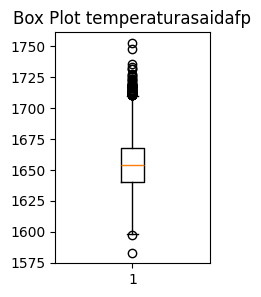

In [156]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturasaidafp)
plt.title("Box Plot temperaturasaidafp")
plt.show()

# Comportamento de Temperaturamediareal

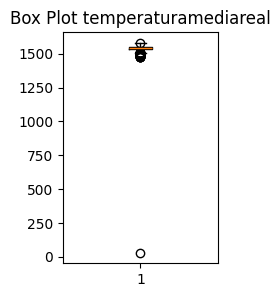

In [157]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturamediareal)
plt.title("Box Plot temperaturamediareal")
plt.show()

**Retirando outlier absurdo e plotando novamente**

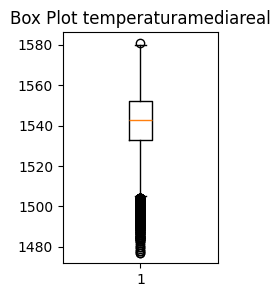

In [158]:
df = df[(df.temperaturamediareal > 500)]
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturamediareal)
plt.title("Box Plot temperaturamediareal")
plt.show()

# Comportamento de Temperaturaobjetivada

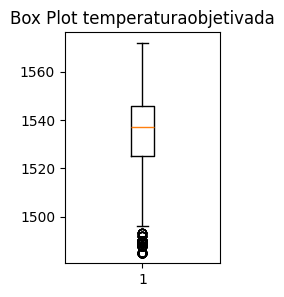

In [159]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.temperaturaobjetivada)
plt.title("Box Plot temperaturaobjetivada")
plt.show()

# Comportamento de VidaPanela

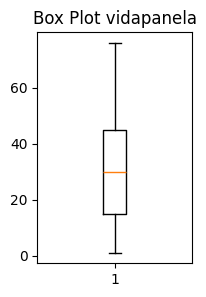

In [160]:
plt.figure(figsize=(2, 3))
plt.boxplot(df.vidapanela)
plt.title("Box Plot vidapanela")
plt.show()

<Axes: >

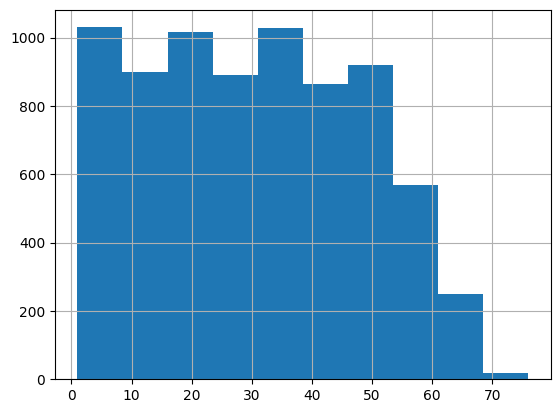

In [161]:
df.vidapanela.hist()
# fazer dispersao 

# Comportamento de Secao

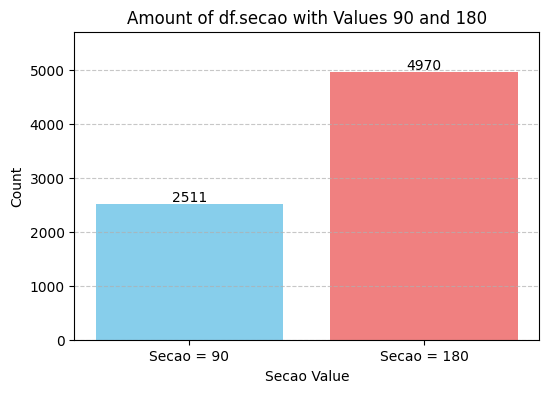

In [162]:
try:
    # Calculate the counts for the desired values
    counts = df['secao'].value_counts()

    # Extract the counts for 90 and 180, defaulting to 0 if they don't exist
    count_90 = counts.get(90)
    count_180 = counts.get(180)

    # Prepare data for plotting
    labels = ['Secao = 90', 'Secao = 180']
    amounts = [count_90, count_180]

    # Create the bar chart
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, amounts, color=['skyblue', 'lightcoral'])

    # Add the count values on top of the bars for clarity
    for bar in bars:
        yval = bar.get_height()
        # Only show text if count > 0
        if yval > 0:
            plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom')

    plt.title('Amount of df.secao with Values 90 and 180')
    plt.xlabel('Secao Value')
    plt.ylabel('Count')
    # Set y limit slightly higher than max count
    plt.ylim(0, max(amounts) * 1.15 if amounts else 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show() 

except Exception as e:
    print(f"An error occurred: {e}")
    plt.show()
    # Clear the figure
    plt.clf()
    

In [163]:
# Calculate mean temperaturamediareal for secao 90 and 180
mean_90 = df.loc[df['secao'] == 90, 'temperaturamediareal'].mean()
mean_180 = df.loc[df['secao'] == 180, 'temperaturamediareal'].mean()

df.groupby('secao')['temperaturamediareal'].describe()

,count,mean,std,min,25%,50%,75%,max
secao,,,,,,,,
90.0,2511.0,1544.054958,12.761721,1486.0,1536.0,1544.0,1553.0,1581.0
180.0,4970.0,1539.436821,17.010341,1477.0,1531.0,1542.0,1552.0,1578.0


Removi a variavel secao devido a analise feita acima

In [164]:
df = df.drop(columns=['secao'])

# Comportamento de aluminio minimo

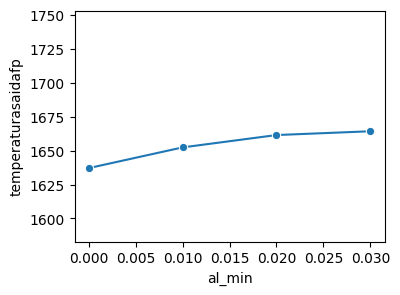

In [165]:
plt.figure(figsize=(4, 3))
sns.lineplot(data=df, x='al_min', y='temperaturasaidafp', estimator='mean', errorbar=None, marker='o')
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.ylim(df['temperaturasaidafp'].min(), df['temperaturasaidafp'].max())
plt.show()

# Comportamento TObjetivada


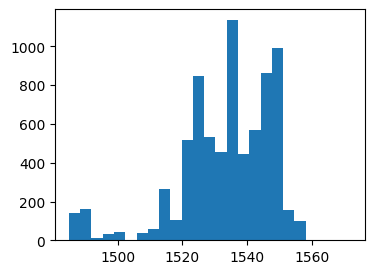

In [166]:
plt.figure(figsize=(4, 3))
plt.hist(df['temperaturaobjetivada'], bins=25)
plt.show()

# Análises do modelo atual em relação a algumas variáveis 

In [167]:
df = df[df['sugestaomodelolegado'] >= 200].copy()

Modelolegado x Tmediareal

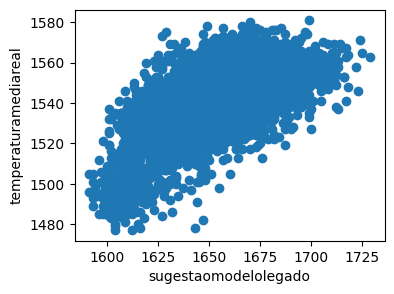

In [168]:
plt.figure(figsize=(4, 3))
plt.scatter(df.sugestaomodelolegado, df.temperaturamediareal)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturamediareal')
plt.show()
#o gráfico mostra que o modelo legado está muito disperso em relação a tmediareal

Modelolegado x Tobjetivada

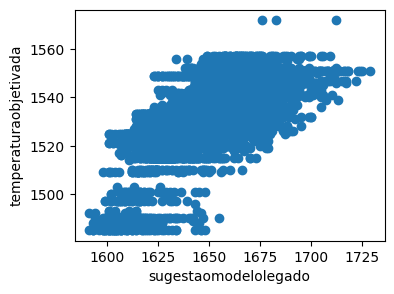

In [169]:
plt.figure(figsize=(4, 3))
plt.scatter(df.sugestaomodelolegado, df.temperaturaobjetivada)
plt.xlabel('sugestaomodelolegado')
plt.ylabel('temperaturaobjetivada')
plt.show()
#o gráfico mostra que o modelo legado está muito disparso em relação a temperatura objetivada

In [170]:
#A variável corrida só serviu para limpar valores duplicados, não tem mais utilidade, deve ser removida

df = df.drop(columns=['corrida'])
df.shape

(7477, 20)

# Comportamento da variável target e relação com outras

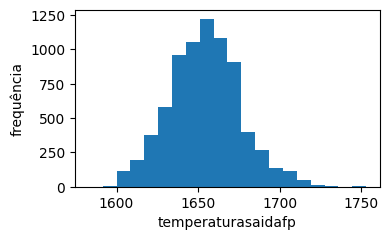

In [171]:
plt.figure(figsize=(4,2.5))
plt.hist(df['temperaturasaidafp'], bins=20)
plt.xlabel('temperaturasaidafp')
plt.ylabel('frequência')
plt.tight_layout()
plt.show()

In [172]:
df['temperaturasaidafp'].describe()

count    7477.000000
mean     1654.000802
std        21.712751
min      1583.000000
25%      1640.000000
50%      1654.000000
75%      1668.000000
max      1753.000000
Name: temperaturasaidafp, dtype: float64

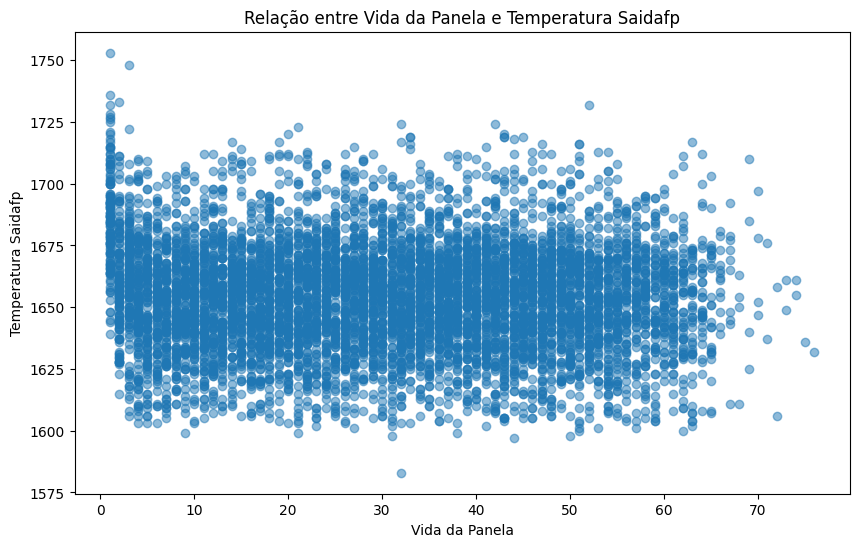

In [173]:
df = df[df.temperaturasaidafp > 500]
plt.figure(figsize=(10, 6))
plt.scatter(df['vidapanela'], df['temperaturasaidafp'], alpha=0.5)
plt.title('Relação entre Vida da Panela e Temperatura Saidafp')
plt.xlabel('Vida da Panela')
plt.ylabel('Temperatura Saidafp')
plt.show()

**Comportamento al_min x target**

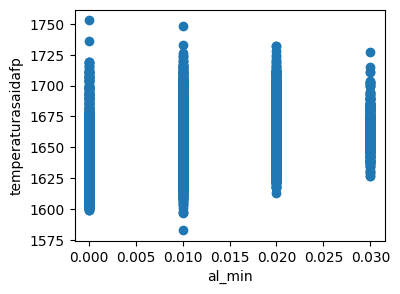

In [174]:
plt.figure(figsize=(4, 3))
plt.scatter(df['al_min'], df['temperaturasaidafp'])
plt.xlabel('al_min')
plt.ylabel('temperaturasaidafp')
plt.show()

# **Avaliação de desempenho do modelo legado**

**Verificando o uso ou não uso do modelo pelos operadores**

In [175]:
df['usage'] = df.apply(
    lambda row: 'usou' if row['sugestaomodelolegado']-row['temperaturasaidafp'] >=-5
    and row['sugestaomodelolegado'] - row['temperaturasaidafp'] <=5
    else 'Naousou',axis=1)
display(df[['temperaturasaidafp', 'sugestaomodelolegado', 'usage']].head())

,temperaturasaidafp,sugestaomodelolegado,usage
0,1670,1648,Naousou
6,1678,1674,usou
28,1672,1651,Naousou
36,1674,1667,Naousou
40,1662,1687,Naousou


In [176]:
# Calculate the percentage of 'usou' and 'Naousou' in the 'usage' column
usage_percentage = df['usage'].value_counts(normalize=True) * 100

# Print the percentages
print("Porcentagem de 'usou' e 'Naousou':")
print(usage_percentage)

Porcentagem de 'usou' e 'Naousou':
usage
usou       56.840979
Naousou    43.159021
Name: proportion, dtype: float64


**Verificando a porcentagem de acerto do modelo legado**

In [177]:
df['diferenca'] = df['sugestaomodelolegado'] - df['temperaturasaidafp']
display(df[['sugestaomodelolegado', 'temperaturasaidafp', 'diferenca']].head())

,sugestaomodelolegado,temperaturasaidafp,diferenca
0,1648,1670,-22
6,1674,1678,-4
28,1651,1672,-21
36,1667,1674,-7
40,1687,1662,25


In [178]:
df['nova_temperatura'] = df['diferenca'] + df['temperaturamediareal']
display(df[['diferenca', 'temperaturamediareal', 'nova_temperatura']].head())

,diferenca,temperaturamediareal,nova_temperatura
0,-22,1555.0,1533.0
6,-4,1547.0,1543.0
28,-21,1556.0,1535.0
36,-7,1540.0,1533.0
40,25,1550.0,1575.0


In [179]:
def check_temperature_range(row):
    nova_temperatura = row['nova_temperatura']
    temperatura_objetivada = row['temperaturaobjetivada']
    if (nova_temperatura >= temperatura_objetivada - 5) and (nova_temperatura <= temperatura_objetivada + 10):
        return 'acerto'
    elif nova_temperatura < (temperatura_objetivada - 5):
        return 'erro para baixo'
    else: # nova_temperatura > (temperatura_objetivada + 10)
        return 'erro para cima'
df_teste = df[df['usage'] == 'usou'].copy()
df_teste['flag_nova_temperatura'] = df_teste.apply(check_temperature_range, axis=1)
display(df_teste[['nova_temperatura', 'temperaturaobjetivada', 'flag_nova_temperatura']].head())
df_teste.shape

,nova_temperatura,temperaturaobjetivada,flag_nova_temperatura
6,1543.0,1543.0,acerto
49,1542.0,1537.0,acerto
60,1536.0,1537.0,acerto
63,1534.0,1537.0,acerto
73,1539.0,1537.0,acerto


(4250, 24)

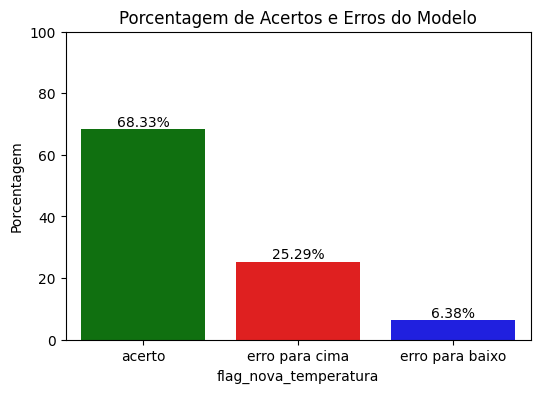

In [180]:
# Calculate the percentage of 'acerto' and 'erro'
flag_counts = df_teste['flag_nova_temperatura'].value_counts(normalize=True) * 100

# Create a bar plot
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette=['green', 'red', 'blue'], hue=flag_counts.index, legend=False)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros do Modelo')
plt.ylim(0, 100)
plt.show()

**Verificando acertos e erros dos dados originais**

In [181]:
df_original = df[df['usage'] != 'usou'].copy()  
df_original.shape

(3227, 23)

C:\Users\crisw\AppData\Local\Temp\ipykernel_19652\1065938361.py:23: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=flag_counts_original.index, y=flag_counts_original.values, palette=['green', 'red'], hue=flag_counts_original.index, legend=False)


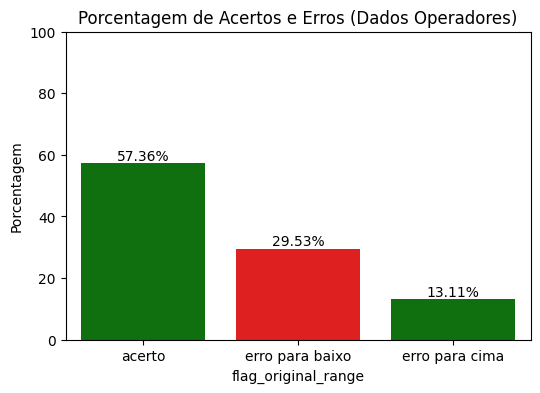

In [182]:
# Check if the original temperaturamediareal is within the desired range of temperaturaobjetivada
is_within_range_original = (df_original['temperaturamediareal'] >= df_original['temperaturaobjetivada'] - 5) & \
                           (df_original['temperaturamediareal'] <= df_original['temperaturaobjetivada'] + 10)
is_within_range = (df['temperaturamediareal'] >= df['temperaturaobjetivada'] - 5) & \
                   (df['temperaturamediareal'] <= df['temperaturaobjetivada'] + 10)
def check_original_temperature_range(row):
    nova_temperatura = row['nova_temperatura']
    temperatura_objetivada = row['temperaturaobjetivada']   
    if (nova_temperatura >= temperatura_objetivada - 5) and (nova_temperatura <= temperatura_objetivada + 10):
        return 'acerto'
    elif nova_temperatura < (temperatura_objetivada - 5):
        return 'erro para baixo'
    else : # nova_temperatura > (temperatura_objetivada + 10)
        return 'erro para cima'
# Create a new column to flag these cases
df_original['flag_original_range'] = df_original.apply(check_original_temperature_range, axis=1)
df['flag_original_range'] = df.apply(check_original_temperature_range, axis=1)
# Calculate the percentage of 'acerto' and 'erro' for the original data
flag_counts_original = df_original['flag_original_range'].value_counts(normalize=True) * 100
flag_counts = df['flag_original_range'].value_counts(normalize=True) * 100
# Create a bar plot for the original data
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts_original.index, y=flag_counts_original.values, palette=['green', 'red'], hue=flag_counts_original.index, legend=False)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros (Dados Operadores)')
plt.ylim(0, 100)
plt.show()

C:\Users\crisw\AppData\Local\Temp\ipykernel_19652\1768987183.py:3: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette=['green', 'red'], hue=flag_counts.index, legend=False)


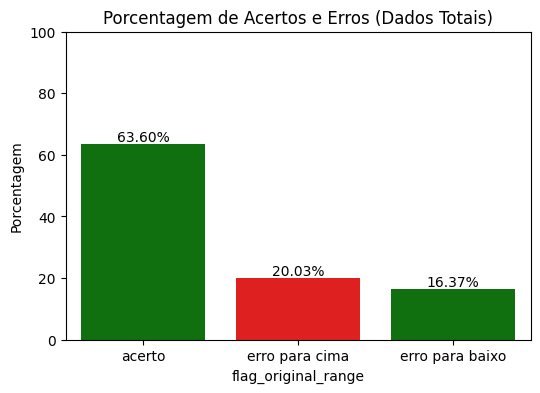

In [183]:
# Create a bar plot for the original data
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=flag_counts.index, y=flag_counts.values, palette=['green', 'red'], hue=flag_counts.index, legend=False)

# Add percentage labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.ylabel('Porcentagem')
plt.title('Porcentagem de Acertos e Erros (Dados Totais)')
plt.ylim(0, 100)
plt.show()